1. Importing Libraries

In [52]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import PolynomialFeatures
from sklearn.preprocessing import StandardScaler
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder
from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import accuracy_score, r2_score, mean_squared_error

2. Data Collection

In [6]:
df = pd.read_csv('medical_insurance.csv')
df.head()

,age,sex,bmi,children,smoker,region,charges
0,19,female,27.900,0,yes,southwest,16884.92400
1,18,male,33.770,1,no,southeast,1725.55230
2,28,male,33.000,3,no,southeast,4449.46200
3,33,male,22.705,0,no,northwest,21984.47061
4,32,male,28.880,0,no,northwest,3866.85520


3. Data Understanding

In [7]:
df.shape

(2772, 7)

In [8]:
df.dtypes

,0
age,int64
sex,object
bmi,float64
children,int64
smoker,object
region,object
charges,float64


In [9]:
df.describe()

,age,bmi,children,charges
count,2772.000000,2772.000000,2772.000000,2772.000000
mean,39.109668,30.701349,1.101732,13261.369959
std,14.081459,6.129449,1.214806,12151.768945
min,18.000000,15.960000,0.000000,1121.873900
25%,26.000000,26.220000,0.000000,4687.797000
50%,39.000000,30.447500,1.000000,9333.014350
75%,51.000000,34.770000,2.000000,16577.779500
max,64.000000,53.130000,5.000000,63770.428010


In [10]:
df.duplicated().sum()

np.int64(1435)

In [11]:
df.drop_duplicates(inplace = True)

In [12]:
df.duplicated().sum()

np.int64(0)

In [13]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 1337 entries, 0 to 1337
Data columns (total 7 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       1337 non-null   int64  
 1   sex       1337 non-null   object 
 2   bmi       1337 non-null   float64
 3   children  1337 non-null   int64  
 4   smoker    1337 non-null   object 
 5   region    1337 non-null   object 
 6   charges   1337 non-null   float64
dtypes: float64(2), int64(2), object(3)
memory usage: 83.6+ KB


In [14]:
df.head()

,age,sex,bmi,children,smoker,region,charges
0,19,female,27.900,0,yes,southwest,16884.92400
1,18,male,33.770,1,no,southeast,1725.55230
2,28,male,33.000,3,no,southeast,4449.46200
3,33,male,22.705,0,no,northwest,21984.47061
4,32,male,28.880,0,no,northwest,3866.85520


   Outlier handling

<Axes: >

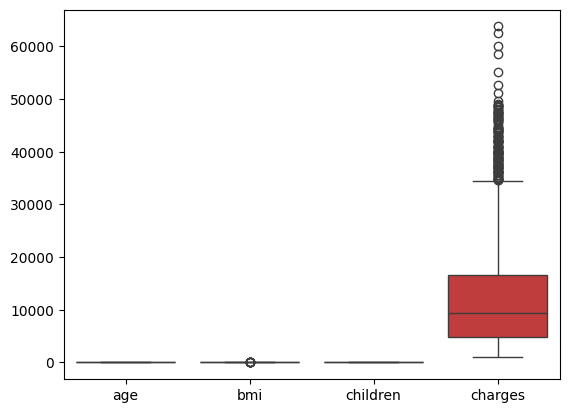

In [15]:
sns.boxplot(df)

/tmp/ipykernel_509/4168411822.py:1: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(df['bmi'])


<Axes: xlabel='bmi', ylabel='Density'>

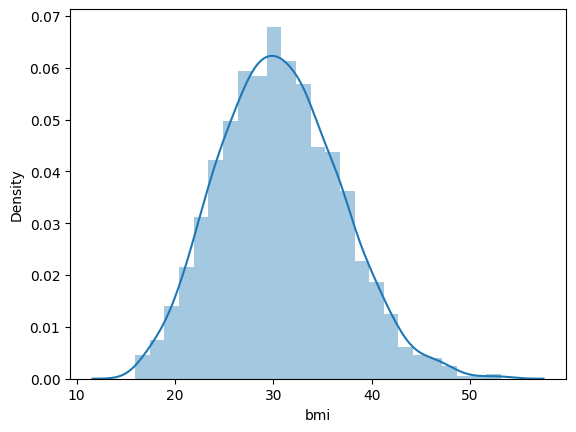

In [16]:
sns.distplot(df['bmi'])

/tmp/ipykernel_509/1319113370.py:1: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(df['charges'])


<Axes: xlabel='charges', ylabel='Density'>

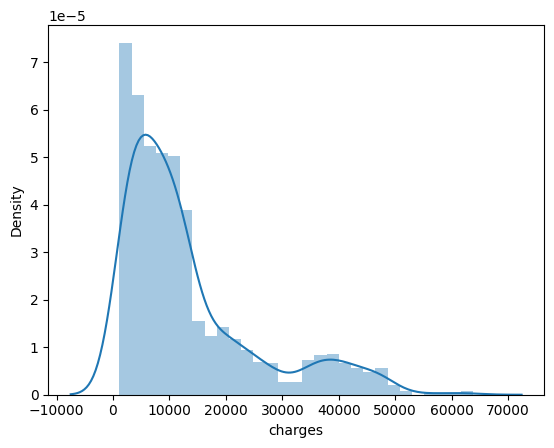

In [17]:
sns.distplot(df['charges'])

   Applying log transformation to target to remove extreme outliers
      (Log transformation compresses large values while keeping small values relatively more separated.)

In [18]:
df['charges_log'] = np.log(df['charges'])

In [19]:
df['charges_log'].describe()

,charges_log
count,1337.000000
mean,9.099928
std,0.918699
min,7.022756
25%,8.465130
50%,9.146992
75%,9.720629
max,11.063045


In [20]:
df = df.drop(columns = ['charges'])

In [21]:
df.head()

,age,sex,bmi,children,smoker,region,charges_log
0,19,female,27.900,0,yes,southwest,9.734176
1,18,male,33.770,1,no,southeast,7.453302
2,28,male,33.000,3,no,southeast,8.400538
3,33,male,22.705,0,no,northwest,9.998092
4,32,male,28.880,0,no,northwest,8.260197


<Axes: ylabel='charges_log'>

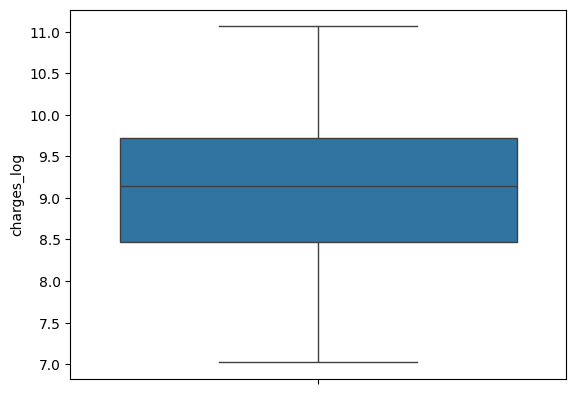

In [22]:
sns.boxplot(df['charges_log'])

here, features -> age, sex, bmi, children, smoker, region &
      target -> charges_log

4. Data Preparation

In [32]:
X = df.drop(columns = ['charges_log'])
y = df['charges_log']

In [33]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.2, random_state = 42)

      4.1 Encoding Categorical Data

       Does the category have an order?

            Yes → Ordinal encoding
            No → One-hot encoding
            Binary → Mapping or one-hot
            Target → Encode according to the ML problem

In [36]:
df.select_dtypes(include = 'object').columns

Index(['sex', 'smoker', 'region'], dtype='object')

In [37]:
categorical_columns = ['sex', 'smoker', 'region']
preprocessor = ColumnTransformer(transformers = [('encoder', OneHotEncoder(), categorical_columns)], remainder = 'passthrough')

              ColumnTransformer allows you to apply different preprocessing operations to different columns.
              "After encoding my categorical columns, keep all the other columns unchanged."
              Don't fit on test set

In [38]:
X_train_encoded = preprocessor.fit_transform(X_train)
X_test_encoded = preprocessor.transform(X_test)

In [41]:
X_train_encoded.shape

(1069, 11)

In [42]:
X_test_encoded.shape

(268, 11)

5.  Model Building, training, Testing & Evaluation

        5.1 Linear Regression

In [48]:
lin_model = LinearRegression()
lin_model.fit(X_train_encoded, y_train)

LinearRegression()

In [49]:
y_pred_lin = lin_model.predict(X_test_encoded)

In [50]:
print("Linear regression Metrics:")
print("R2 Score:", r2_score(y_test, y_pred_lin))
print("MSE:", mean_squared_error(y_test, y_pred_lin))
print("RMSE:", np.sqrt(mean_squared_error(y_test, y_pred_lin)))

Linear regression Metrics:
R2 Score: 0.8294642959644741
MSE: 0.15828783951190942
RMSE: 0.39785404297544774


    5.2 Polynomial Regression

In [53]:
poly = PolynomialFeatures(degree = 2)
X_train_poly = poly.fit_transform(X_train_encoded)
X_test_poly = poly.transform(X_test_encoded)

In [54]:
poly_model = LinearRegression()
poly_model.fit(X_train_poly, y_train)

LinearRegression()

In [55]:
y_pred_poly = poly_model.predict(X_test_poly)

In [56]:
print("Polynomial regression Metrics:")
print("R2 Score:", r2_score(y_test, y_pred_poly))
print("MSE:", mean_squared_error(y_test, y_pred_poly))
print("RMSE:", np.sqrt(mean_squared_error(y_test, y_pred_poly)))

Polynomial regression Metrics:
R2 Score: 0.8860043124623227
MSE: 0.1058085237696307
RMSE: 0.32528222172389115


    5.3 Ridge Regression

In [57]:
ridge_model = Ridge(alpha=1.0)
ridge_model.fit(X_train_encoded, y_train)

Ridge()

In [60]:
y_pred_ridge = ridge_model.predict(X_test_encoded)

In [61]:
print("Ridge regression Metrics:")
print("R2 Score:", r2_score(y_test, y_pred_ridge))
print("MSE:", mean_squared_error(y_test, y_pred_ridge))
print("RMSE:", np.sqrt(mean_squared_error(y_test, y_pred_ridge)))


Ridge regression Metrics:
R2 Score: 0.829308342380134
MSE: 0.15843259251872954
RMSE: 0.3980359186288714


    5.4 Lasso Regression

In [63]:
lasso_model = Lasso(alpha=0.01)
lasso_model.fit(X_train_encoded, y_train)

Lasso(alpha=0.01)

In [64]:
y_pred_lasso = lasso_model.predict(X_test_encoded)

In [68]:
print("Lasso regression Metrics:")
print("R2 Score:", r2_score(y_test, y_pred_lasso))
print("MSE:", mean_squared_error(y_test, y_pred_lasso))
print("RMSE:", np.sqrt(mean_squared_error(y_test, y_pred_lasso)))

Lasso regression Metrics:
R2 Score: 0.8205556414533774
MSE: 0.1665566749648405
RMSE: 0.4081135564580531


    5.5 Decision Tree Regression

In [69]:
tree_model = DecisionTreeRegressor(random_state=42)
tree_model.fit(X_train_encoded, y_train)

DecisionTreeRegressor(random_state=42)

In [70]:
y_pred_tree = tree_model.predict(X_test_encoded)

In [71]:
print("Decision Tree regression Metrics:")
print("R2 Score:", r2_score(y_test, y_pred_tree))
print("MSE:", mean_squared_error(y_test, y_pred_tree))
print("RMSE:", np.sqrt(mean_squared_error(y_test, y_pred_tree)))

Decision Tree regression Metrics:
R2 Score: 0.7044644960769237
MSE: 0.27431016091094956
RMSE: 0.5237462753194047


    5.6 Random Forest Regression

In [72]:
forest_model = RandomForestRegressor(random_state=42)
forest_model.fit(X_train_encoded, y_train)

RandomForestRegressor(random_state=42)

In [73]:
y_pred_forest = forest_model.predict(X_test_encoded)

In [74]:
print("Random Forest regression Metrics:")
print("R2 Score:", r2_score(y_test, y_pred_forest))
print("MSE:", mean_squared_error(y_test, y_pred_forest))
print("RMSE:", np.sqrt(mean_squared_error(y_test, y_pred_forest)))

Random Forest regression Metrics:
R2 Score: 0.8505002889416116
MSE: 0.13876265034891086
RMSE: 0.3725085909732967


Best Model Selection:

Best model is Polynomial regression.

Zero Residual Mean Test:

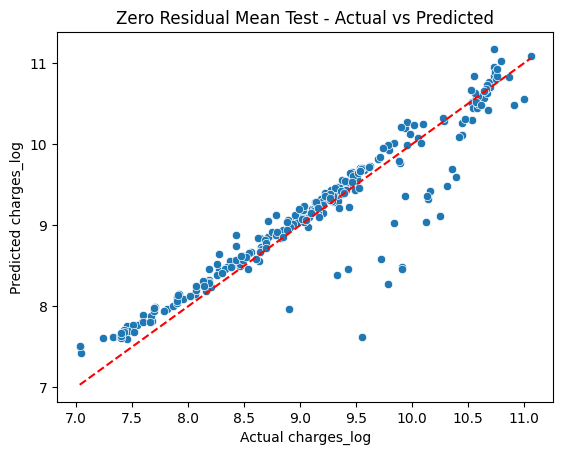

In [79]:
sns.scatterplot(x = y_test, y = y_pred_poly)
plt.xlabel('Actual charges_log')
plt.ylabel('Predicted charges_log')
plt.title('Zero Residual Mean Test - Actual vs Predicted')

plt.plot(
    [y_test.min(), y_test.max()],
    [y_test.min(), y_test.max()],
    'r--'
)
plt.show()

6. Predict for new data

In [80]:
new_customer = pd.DataFrame({
    "age": [35],
    "sex": ["male"],
    "bmi": [28.5],
    "children": [2],
    "smoker": ["no"],
    "region": ["southeast"]
})

In [96]:
new_customer_encoded = preprocessor.transform(new_customer)
new_customer_poly = poly.transform(new_customer_encoded)
predicted_charges_log = poly_model.predict(new_customer_poly)
predicted_charges = np.exp(predicted_charges_log)

print(f"Predicted insurance charges for the new customer: ${predicted_charges[0]:.2f}")

Predicted insurance charges for the new customer: $6143.16


7. Model Deployment

    save model

In [99]:
import joblib

joblib.dump(model, 'medical_insurance_model.pkl')

['medical_insurance_model.pkl']

    load model

In [100]:
model = joblib.load('medical_insurance_model.pkl')